In [1]:
import numpy as np
from netCDF4 import Dataset
import  matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import warnings
import datetime
import time # for sleep
import os.path # for basename
import glob
import xarray as xr
from numpy import savetxt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
from PIL import Image
from global_land_mask import globe
from scipy.interpolate import griddata
import matplotlib.cm as cm
import matplotlib.colors as colors
from rasterio.transform import from_origin

/home/ubuntu/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
datasets = [
    "https://cacheb.dcms.destine.eu/d1-climate-dt/ScenarioMIP-SSP3-7.0-IFS-NEMO-0001-high-sfc-v0.zarr",
    "https://cacheb.dcms.destine.eu/d1-climate-dt/ScenarioMIP-SSP3-7.0-IFS-NEMO-0001-high-sfc-monthly-v0.zarr",
    "https://cacheb.global_land_maskglobal_land_maskglobal_land_maskglobal_land_maskdcms.destine.eu/d1-climate-dt/ScenarioMIP-SSP3-7.0-IFS-NEMO-0001-high-o2d-v0.zarr",
    "https://cacheb.dcms.destine.eu/d1-climate-dt/ScenarioMIP-SSP3-7.0-IFS-NEMO-0001-high-pl-v0.zarr",
    "https://cacheb.dcms.destine.eu/d1-climate-dt/ScenarioMIP-SSP3-7.0-ICON-0001-high-sfc-v0.zarr",
    "https://cacheb.dcms.destine.eu/d1-climate-dt/ScenarioMIP-SSP3-7.0-ICON-0001-high-sfc-monthly-v0.zarr",
    "https://cacheb.dcms.destine.eu/era5/reanalysis-era5-land-no-antartica-v0.zarr",
    "https://cacheb.dcms.destine.eu/era5/reanalysis-era5-single-levels-v0.zarr",
    "https://cacheb.dcms.destine.eu/era5/reanalysis-era5-single-levels-monthly-means-v0.zarr",
    "https://cacheb.dcms.destine.eu/era5/reanalysis-era5-pressure-levels-v0.zarr",
]

In [3]:
%%capture cap
%run cacheb-authentication.py

Username:  qinghuai925
Password:  ········


In [4]:
output_1 = cap.stdout.split('}\n')
token = output_1[-1][0:-1]

from pathlib import Path
with open(Path.home() / ".netrc", "a") as fp:
    fp.write(token)

In [5]:
import xarray as xr

data = xr.open_dataset(
    "https://cacheb.dcms.destine.eu/d1-climate-dt/ScenarioMIP-SSP3-7.0-IFS-NEMO-0001-high-o2d-v0.zarr",
    storage_options={"client_kwargs":{"trust_env":"true"}},
    chunks={},
    engine="zarr",
)

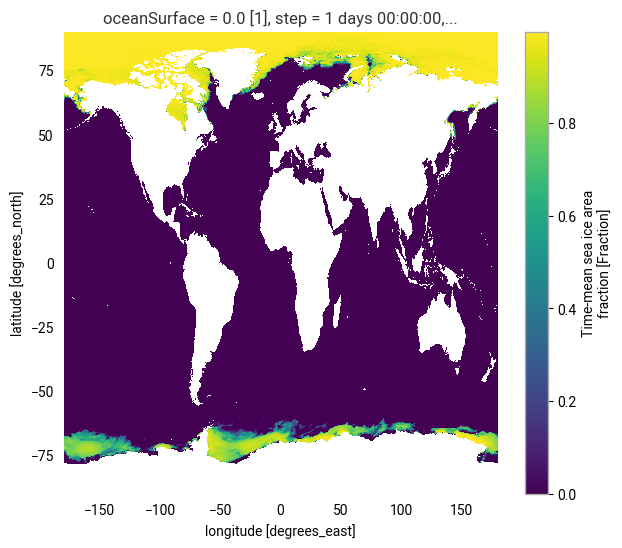

In [8]:
data.avg_siconc[0].plot()

In [17]:
avg_siconc = data.avg_siconc.astype("float32")
avg_siconc.attrs["units"] = ""
avg_siconc_arctic_area = avg_siconc.sel(**{"latitude": slice(40, 90), "longitude": slice(-180, 180)})
avg_sithick = data.avg_sithick.astype("float32")
avg_sithick.attrs["units"] = "m"
avg_sithick_arctic_area = avg_sithick.sel(**{"latitude": slice(40, 90), "longitude": slice(-180, 180)})


In [18]:
avg_siconc_arctic_area.longitude

<xarray.DataArray 'longitude' (longitude: 8193)> Size: 66kB
array([-180.      , -179.956055, -179.912109, ...,  179.912109,  179.956055,
        180.      ])
Coordinates:
  * longitude     (longitude) float64 66kB -180.0 -180.0 -179.9 ... 180.0 180.0
    oceanSurface  float64 8B ...
    step          timedelta64[ns] 8B ...
Attributes:
    long_name:      longitude
    standard_name:  longitude
    units:          degrees_east